# Funding-aware perpetual backtests

**Use case: [Improve your backtest](https://aperiodic.io/use-cases/improve-your-backtest)**

A perpetual-futures position does not only earn the price move — it also pays or
receives **funding** at discrete settlement prints. A price-only backtest ignores
those cash flows and can misattribute carry to trading alpha, most of all for a
persistently **long** strategy in a rising, positive-funding market. This notebook
isolates realised funding and shows exactly where it binds: it is a first-order
cost for a directional (long-biased) position and nets out for a direction-neutral
one.

We use **Binance BTC perpetuals** (`perpetual-BTC-USDT:USDT`) at **5-minute**
resolution over **May 2025**, the window served by the shared `DEMO-KEY` preview
slice.

> **One month is an illustration, not evidence.** The figures below are a worked
> example of *how funding enters PnL*, never proof of a durable edge.

**Background reading**
- Aperiodic derivatives metrics: https://aperiodic.io/metrics/derivatives
- Binance Academy, funding rates: https://www.binance.com/en/academy/articles/what-are-funding-rates-in-crypto-markets

## 1. Funding is part of perp PnL

Perpetual swaps use a **funding** mechanism to keep the contract tethered to the
spot/index price:

- When funding is **positive**, **longs pay shorts**. When it is **negative**,
  **shorts pay longs**.
- Funding is exchanged at **discrete settlements** (Binance settles every 8 hours,
  at 00:00 / 08:00 / 16:00 UTC), not continuously. It accrues to whatever position
  is held **into** the settlement.
- We use **realised** funding only. The catalogue exposes no predicted-funding
  metric, so nothing here forecasts the next print — we account for prints that
  already happened.

The catalogue's `funding_rate` is *"the last funding rate observed in the
interval"* of a continuously-updated feed. The amount actually exchanged at a
settlement is therefore the rate as of that instant — captured by the **last bar
before** the settlement — and it is charged to the **position held into** it. We
implement exactly that convention below and cross-check the cadence.

**Units matter here.** `funding_rate` is a **per-settlement** (per-8h) rate —
e.g. `0.0001` (1bp) means 1bp of notional changes hands at *that print*, not
over a year. All PnL below (Chart 2, Section 6, Chart 3) charges this raw
per-settlement value directly, since that is the actual cash flow. Wherever we
instead want a magnitude that is comparable across venues/instruments with
different settlement cadences, we **annualize** it as
`rate_annualized = rate_per_settlement × settlements_per_year` (3/day × 365 =
`SETTLEMENTS_PER_YEAR` = 1,095 for this venue) — never the other way around, and
never inside a PnL calculation.

In [1]:
from __future__ import annotations

import os
from datetime import date

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from aperiodic import get_derivative_metrics, get_ohlcv

sns.set_theme(style="whitegrid", context="talk", palette="deep")
pd.options.display.float_format = "{:,.6f}".format
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 2. Configuration

Uppercase constants hold the public parameters. The API key resolves **inline
value → `APERIODIC_API_KEY` → `DEMO-KEY`**; with no key the notebook runs
end-to-end on the `DEMO-KEY` preview slice.

In [2]:
EXCHANGE = "binance-futures"
SYMBOL = "perpetual-BTC-USDT:USDT"
INTERVAL = "5m"
START_DATE = date(2025, 5, 1)
END_DATE = date(2025, 5, 31)
TIMESTAMP = "exchange"
START_TS = pd.Timestamp(START_DATE)
END_TS = pd.Timestamp(END_DATE) + pd.Timedelta(days=1)

# Binance USDT-M perp funding settles every 8 hours at these UTC hours.
SETTLEMENT_HOURS = (0, 8, 16)
# Settlements/year, for converting a per-print rate to an annualized (APR) one.
SETTLEMENTS_PER_YEAR = len(SETTLEMENT_HOURS) * 365
# Lookback (bars) for the direction-neutral toy momentum comparison; 12 bars = 1h.
MOMENTUM_LOOKBACK = 12
# Near-zero band (bps) for shading the funding regime chart.
FUNDING_ZERO_BAND_BPS = 0.5

API_KEY = "..."  # Set your key here, or via the APERIODIC_API_KEY env var
if API_KEY == "...":
    API_KEY = os.environ.get("APERIODIC_API_KEY", "DEMO-KEY")

# Only the shared "DEMO-KEY" runs against the preview endpoint. Provide your own
# key (above or via APERIODIC_API_KEY) to use the standard endpoint.
USE_PREVIEW = API_KEY == "DEMO-KEY"

print(f"Exchange / symbol : {EXCHANGE} / {SYMBOL}")
print(f"Interval / window : {INTERVAL} | {START_DATE} → {END_DATE}")
print(f"Mode              : {'preview (DEMO-KEY)' if USE_PREVIEW else 'standard endpoint'}")

Exchange / symbol : binance-futures / perpetual-BTC-USDT:USDT
Interval / window : 5m | 2025-05-01 → 2025-05-31
Mode              : standard endpoint


## Helper functions

`clip_window` and `format_time_axis` match the introductory notebooks;
`run_position_backtest` is the same 5-minute-annualised backtest used in
`most-predictive.py` and `alpha-discovery.py`; `funding_settlement_mask` marks the
8-hour settlement bars (with a guarded stepwise fallback); and `audit_columns`
prints the fetched schema and fails loudly if a required field is absent.

In [3]:
def clip_window(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])
    out = out.loc[(out["time"] >= START_TS) & (out["time"] < END_TS)]
    return out.sort_values("time").reset_index(drop=True)


def format_time_axis(ax):
    locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)


def audit_columns(frames: dict[str, tuple[pd.DataFrame, list[str]]]) -> None:
    lines, problems = [], []
    for name, (frame, required) in frames.items():
        cols = sorted(map(str, frame.columns))
        missing = [c for c in required if c not in frame.columns]
        lines.append(f"- {name:<14} {len(frame):>5} rows | columns={cols}")
        if missing:
            problems.append(f"{name} missing {missing}")
    report = "Fetched schema:\n" + "\n".join(lines)
    print(report)
    if problems:
        raise KeyError("; ".join(problems) + "\n" + report)


def funding_settlement_mask(frame: pd.DataFrame) -> pd.Series:
    """Mark the funding-settlement bars. Binance USDT-M perps settle every 8 hours
    at ``SETTLEMENT_HOURS`` UTC, which we detect directly from the timestamp — the
    reliable path for this venue.

    This is deliberately **not** claimed to be venue-agnostic. If the standard
    schedule is absent (a different venue/symbol) we fall back to change-detection,
    which assumes a **stepwise** feed. The catalogue funding feed updates *within*
    each window (`funding_rate_update_frequency` > 0), so on a continuously-updated
    feed change-detection would flag nearly every bar and massively over-accrue;
    we raise rather than do that silently."""
    t = frame["time"]
    scheduled = t.dt.hour.isin(SETTLEMENT_HOURS) & (t.dt.minute == 0)
    if int(scheduled.sum()) >= 3:
        return scheduled
    fr = frame["funding_rate"]
    changes = fr.notna() & fr.ne(fr.shift()) & fr.shift().notna()  # excludes row 0
    n_changes = int(changes.sum())
    expected_windows = len(frame) * 5 / (60 * 8)  # 5m bars -> number of 8h windows
    if n_changes > 3 * expected_windows:
        raise ValueError(
            f"{n_changes} funding-rate changes across {len(frame)} bars looks like a "
            "continuously-updated feed, not a stepwise one; set the venue's "
            "settlement schedule explicitly instead of relying on change-detection."
        )
    return changes


def run_position_backtest(
    timestamps: pd.Series,
    position: np.ndarray,
    forward_return: np.ndarray,
    cost_bps_one_way: float | np.ndarray = 0.0,
) -> tuple[pd.DataFrame, dict]:
    """Vectorised long/short backtest; annualisation assumes 5-minute bars."""
    position = np.asarray(position, dtype=np.float64)
    forward_return = np.asarray(forward_return, dtype=np.float64)

    gross_pnl = position * forward_return
    turnover = np.abs(np.diff(position, prepend=0.0))
    cost = turnover * np.asarray(cost_bps_one_way, dtype=np.float64) / 1e4
    net_pnl = gross_pnl - cost
    equity = np.cumprod(1.0 + net_pnl)

    if equity.size == 0:
        bt_frame = pd.DataFrame({"timestamp": timestamps.to_numpy(), "equity_curve": equity})
        return bt_frame, {"annualized_sharpe": 0.0, "net_return_pct": 0.0, "max_drawdown_pct": 0.0}

    running_max = np.maximum.accumulate(equity)
    drawdowns = (equity - running_max) / running_max
    max_drawdown_pct = float(np.min(drawdowns)) * 100.0

    bars_per_year = 288 * 365
    mean_ret = float(np.mean(net_pnl))
    std_ret = float(np.std(net_pnl, ddof=1)) if len(net_pnl) > 1 else 1.0
    annualized_sharpe = (mean_ret / std_ret) * np.sqrt(bars_per_year) if std_ret > 0 else 0.0
    net_return_pct = float((equity[-1] / equity[0] - 1.0) * 100.0)

    bt_frame = pd.DataFrame({"timestamp": timestamps.to_numpy(), "equity_curve": equity})
    bt_summary = {
        "annualized_sharpe": float(annualized_sharpe),
        "net_return_pct": net_return_pct,
        "max_drawdown_pct": max_drawdown_pct,
    }
    return bt_frame, bt_summary

## 3. Fetch price and realised funding

The price and funding requests share the common arguments (`api_key`, `preview`,
`timestamp`, `interval`, `exchange`, `symbol`, `start_date`, `end_date`,
`output="pandas"`, `show_progress=False`). We detect the settlement bars, then
take the **settled rate** as the last funding value observed *before* each
settlement.

In [4]:
COMMON = dict(
    api_key=API_KEY,
    preview=USE_PREVIEW,
    timestamp=TIMESTAMP,
    interval=INTERVAL,
    exchange=EXCHANGE,
    symbol=SYMBOL,
    start_date=START_DATE,
    end_date=END_DATE,
    output="pandas",
    show_progress=False,
)

ohlcv = clip_window(get_ohlcv(**COMMON))
funding = clip_window(get_derivative_metrics(metric="funding", **COMMON))

audit_columns(
    {
        "ohlcv": (ohlcv, ["time", "close"]),
        "funding": (funding, ["time", "funding_rate"]),
    }
)

Fetched schema:
- ohlcv           8928 rows | columns=['close', 'high', 'low', 'open', 'time', 'volume', 'volume_notional']
- funding         8928 rows | columns=['funding_rate', 'funding_rate_avg_update_interval', 'funding_rate_update_frequency', 'time']


In [5]:
df = ohlcv[["time", "close"]].merge(funding[["time", "funding_rate"]], on="time", how="inner")
df = df.sort_values("time").reset_index(drop=True)
df["funding_rate_ff"] = df["funding_rate"].ffill()
df["ret"] = df["close"].pct_change()

# Settlement bars, and the rate settled at each = the last observed rate BEFORE the
# settlement (the previous bar), per the catalogue "last rate in interval" feed.
df["is_settlement"] = funding_settlement_mask(df)
df["settled_rate"] = df["funding_rate_ff"].shift(1)  # valid at settlement bars

settled = df.loc[df["is_settlement"], ["time", "settled_rate"]].dropna().reset_index(drop=True)
settled["settled_rate_bps"] = settled["settled_rate"] * 1e4
settled["settled_rate_annualized_pct"] = settled["settled_rate"] * SETTLEMENTS_PER_YEAR * 100

# Cadence cross-check: settlements should be ~8h apart and number ~3/day.
gaps_h = settled["time"].diff().dropna().dt.total_seconds() / 3600
coverage = pd.Series(
    {
        "Rows (5m bars)": len(df),
        "Settlements detected": len(settled),
        "Expected (~3/day)": round(len(df) * 5 / (60 * 8)),
        "Median gap between settlements (h)": gaps_h.median() if len(gaps_h) else np.nan,
        "Mean settled funding, per print (bps)": settled["settled_rate_bps"].mean(),
        "Mean settled funding, annualized (%)": settled["settled_rate_annualized_pct"].mean(),
        "Share of positive settlements": (settled["settled_rate"] > 0).mean(),
    }
)
print(coverage.to_string())
print(
    "\nThe first in-window settlement (May 1, 00:00) has no pre-window bar, so its settled_rate "
    "(funding_rate_ff.shift(1)) is NaN and it is dropped — the position holding into it was "
    "established before the window, so there is nothing to charge; hence detected = expected − 1."
)
print(
    "Convention: each settlement is charged the rate from the bar before it, applied to the "
    "position held into it. A definitive audit would reconcile 2–3 of these against Binance's "
    "published funding history (external to this catalogue)."
)

Rows (5m bars)                          8,928.000000
Settlements detected                       92.000000
Expected (~3/day)                          93.000000
Median gap between settlements (h)          8.000000
Mean settled funding, per print (bps)       0.464864
Mean settled funding, annualized (%)        5.090263
Share of positive settlements               0.902174

The first in-window settlement (May 1, 00:00) has no pre-window bar, so its settled_rate (funding_rate_ff.shift(1)) is NaN and it is dropped — the position holding into it was established before the window, so there is nothing to charge; hence detected = expected − 1.
Convention: each settlement is charged the rate from the bar before it, applied to the position held into it. A definitive audit would reconcile 2–3 of these against Binance's published funding history (external to this catalogue).


## 4. Chart 1 — Funding regimes

The funding feed updates within each window, so we draw the raw rate as a thin
line and mark the **settled** value at each 8-hour print. Positive (longs pay),
negative (shorts pay), and near-zero regimes are shaded. The left axis is the
**per-print** rate actually exchanged at each settlement; the right axis is the
same series **annualized** (`× SETTLEMENTS_PER_YEAR`) purely for scale — it is
not itself a cash flow.

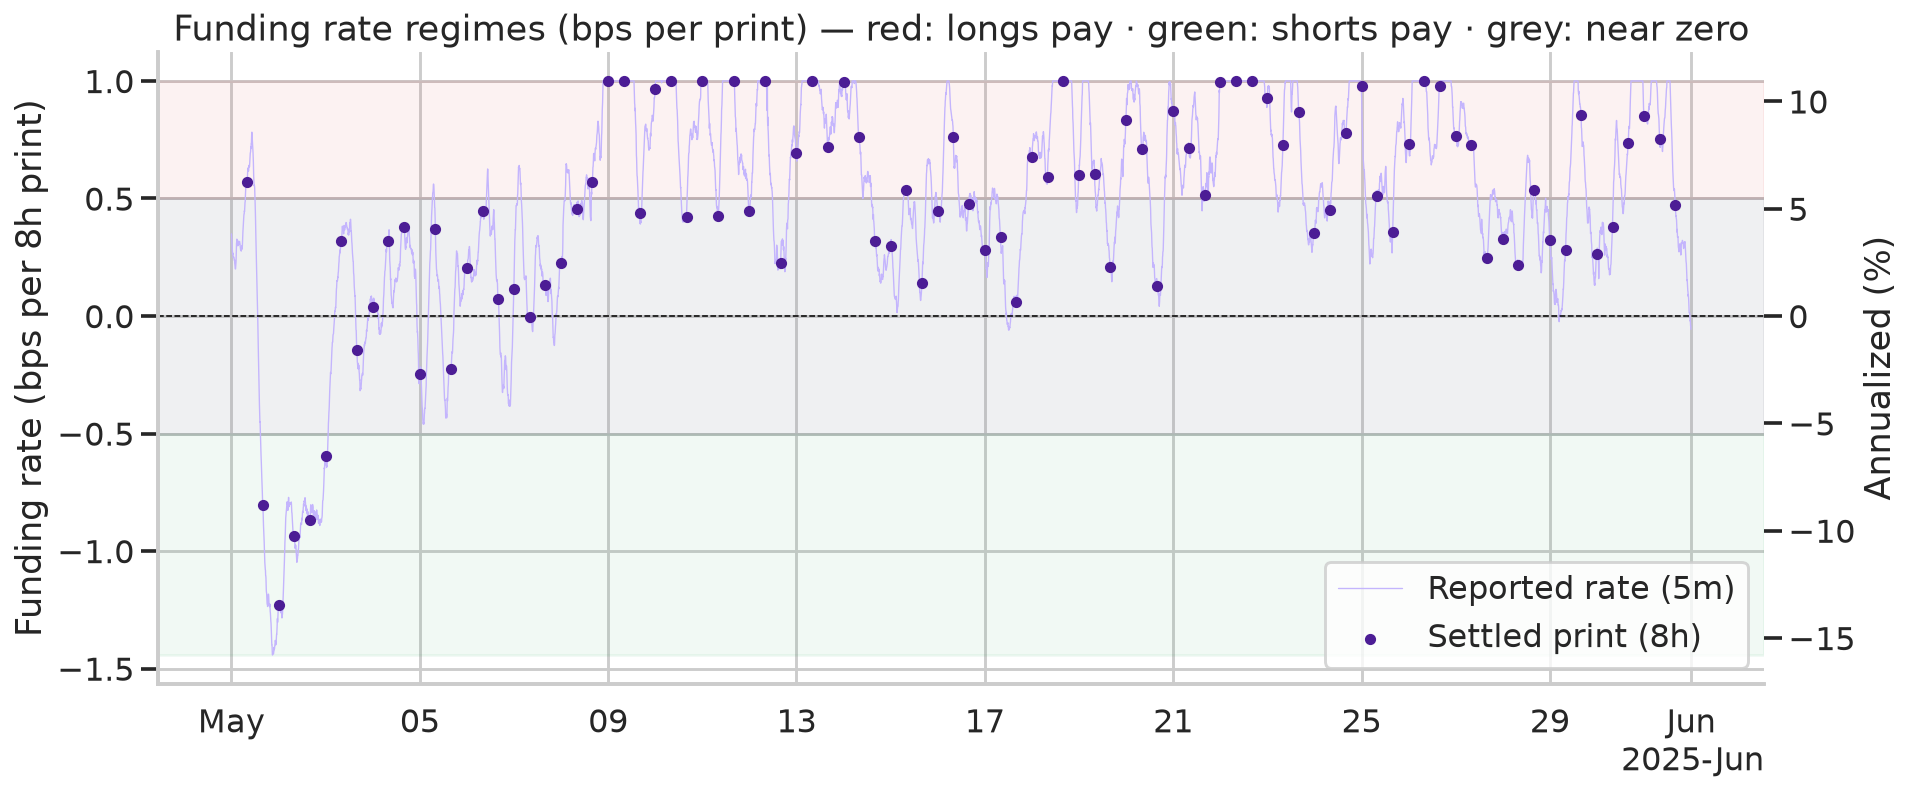

In [6]:
df["funding_rate_bps"] = df["funding_rate_ff"] * 1e4
fig, ax = plt.subplots(figsize=(14, 6))
ax.axhspan(FUNDING_ZERO_BAND_BPS, df["funding_rate_bps"].max(), color="#dc2626", alpha=0.06)
ax.axhspan(df["funding_rate_bps"].min(), -FUNDING_ZERO_BAND_BPS, color="#16a34a", alpha=0.06)
ax.axhspan(-FUNDING_ZERO_BAND_BPS, FUNDING_ZERO_BAND_BPS, color="#6b7280", alpha=0.10)
ax.plot(df["time"], df["funding_rate_bps"], color="#c4b5fd", linewidth=0.7, label="Reported rate (5m)")
ax.scatter(settled["time"], settled["settled_rate_bps"], s=18, color="#4c1d95", zorder=5, label="Settled print (8h)")
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Funding rate regimes (bps per print) — red: longs pay · green: shorts pay · grey: near zero")
ax.set_ylabel("Funding rate (bps per 8h print)")
ax.legend(frameon=True)
ax_ann = ax.twinx()
ax_ann.set_ylim(np.array(ax.get_ylim()) * SETTLEMENTS_PER_YEAR / 100)
ax_ann.set_ylabel("Annualized (%)")
ax_ann.grid(False)
format_time_axis(ax)
plt.tight_layout()

## 5. Chart 2 — Cumulative funding for a constant long

Hold a **constant unit long** and accrue the settled funding at each print. A long
**pays** when the rate is positive, so the realised funding cash flow at a print is

> `funding_pnl = -position × settled_rate`   (position = +1 here)

A downward-sloping curve means the long is *paying* to hold — carry a price-only
backtest never subtracts.

Net funding for a constant unit long over the window: -0.4277% of notional


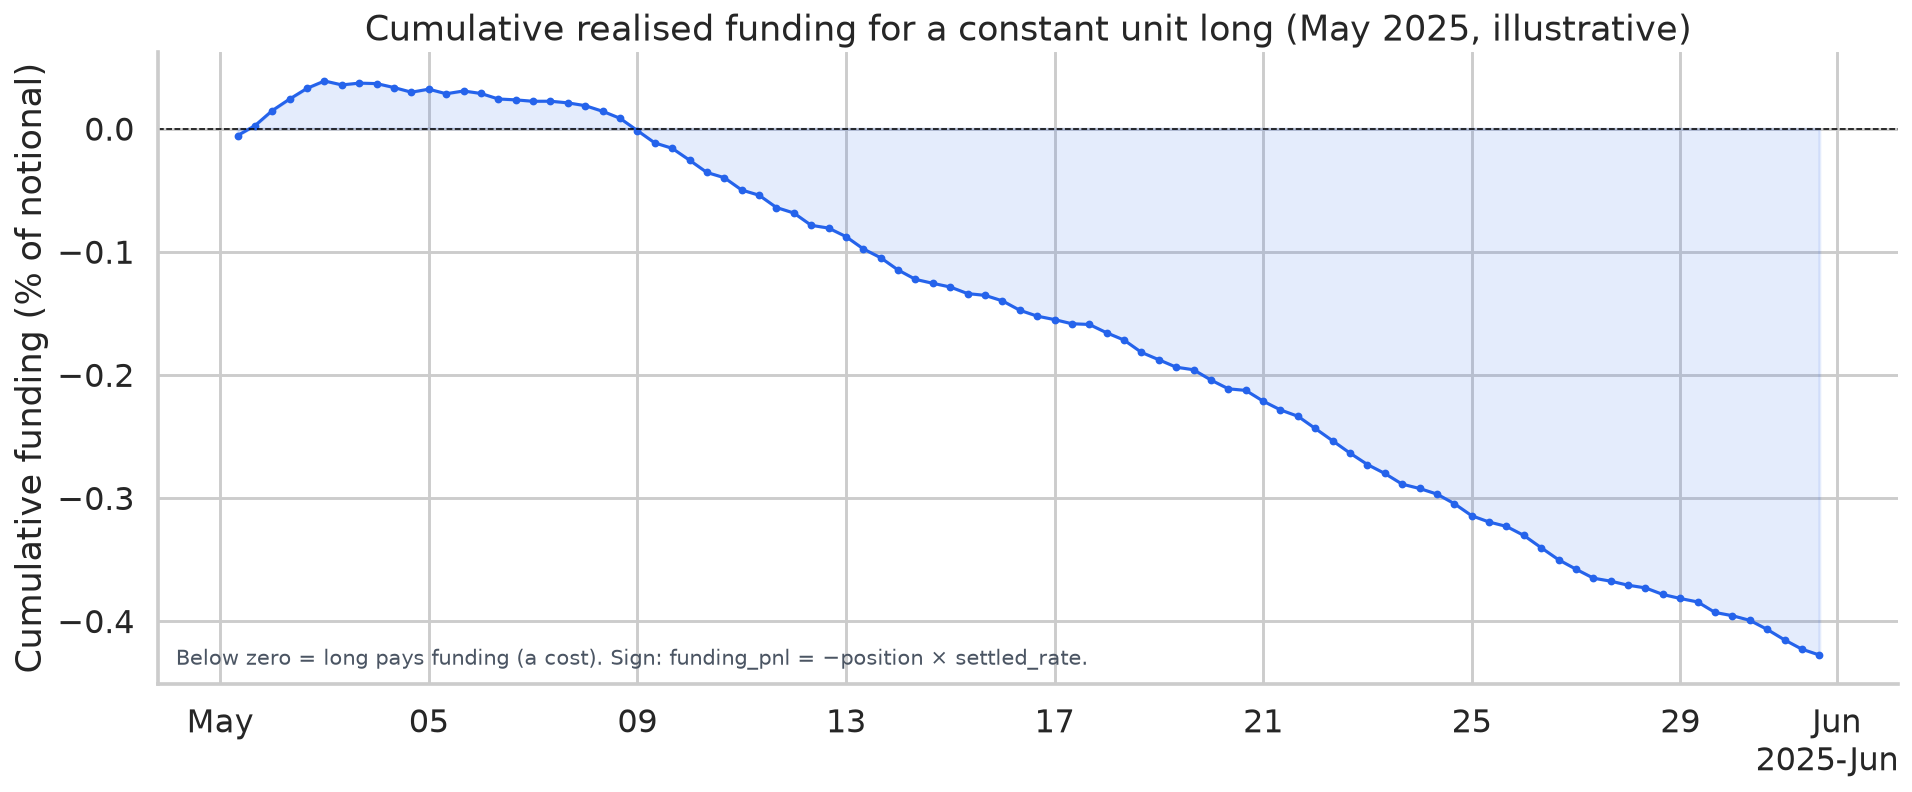

In [7]:
settled = settled.copy()
settled["cum_funding_unit_long_pct"] = (-settled["settled_rate"]).cumsum() * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(settled["time"], settled["cum_funding_unit_long_pct"], color="#2563eb", linewidth=1.6, marker="o", markersize=3)
ax.fill_between(settled["time"], settled["cum_funding_unit_long_pct"], alpha=0.12, color="#2563eb")
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Cumulative realised funding for a constant unit long (May 2025, illustrative)")
ax.set_ylabel("Cumulative funding (% of notional)")
ax.text(
    0.01, 0.03,
    "Below zero = long pays funding (a cost). Sign: funding_pnl = −position × settled_rate.",
    transform=ax.transAxes, fontsize=11, color="#4b5563",
)
format_time_axis(ax)
plt.tight_layout()
print(f"Net funding for a constant unit long over the window: {settled['cum_funding_unit_long_pct'].iloc[-1]:.4f}% of notional")

## 6. Does funding change the backtest? It depends on direction.

We compare **price-only** against **price + funding** for two positions, holding
the accounting identical:

1. a **constant unit long** — a directional, long-biased position, and
2. a **1-hour momentum** signal (sign of the mean return over `MOMENTUM_LOOKBACK`
   bars) — roughly direction-neutral across the month.

Funding is added by adjusting the return leg at the settlement bars only, charged
to the **position held into** each settlement (the bar before it), so turnover is
never touched:

> `funding_leg[t] = settled_rate · 1[bar t+1 is a settlement]`,  `fret_with_funding = fret − funding_leg`

Execution/turnover costs are the subject of `backtest-slippage.py` and are omitted
here so the funding effect is isolated.

| position      |   price_only_return_pct |   price_plus_funding_return_pct |   funding_contribution_pct |
|:--------------|------------------------:|--------------------------------:|---------------------------:|
| Constant long |                10.9145  |                        10.4411  |                  -0.427675 |
| 1h momentum   |                 2.47313 |                         2.41968 |                  -0.052123 |

funding_contribution_pct is an additive approximation (sum of settlement cash flows); returns compound, so it need not reconcile exactly with the return columns. Note the direction-neutral momentum signal nets funding out almost entirely.


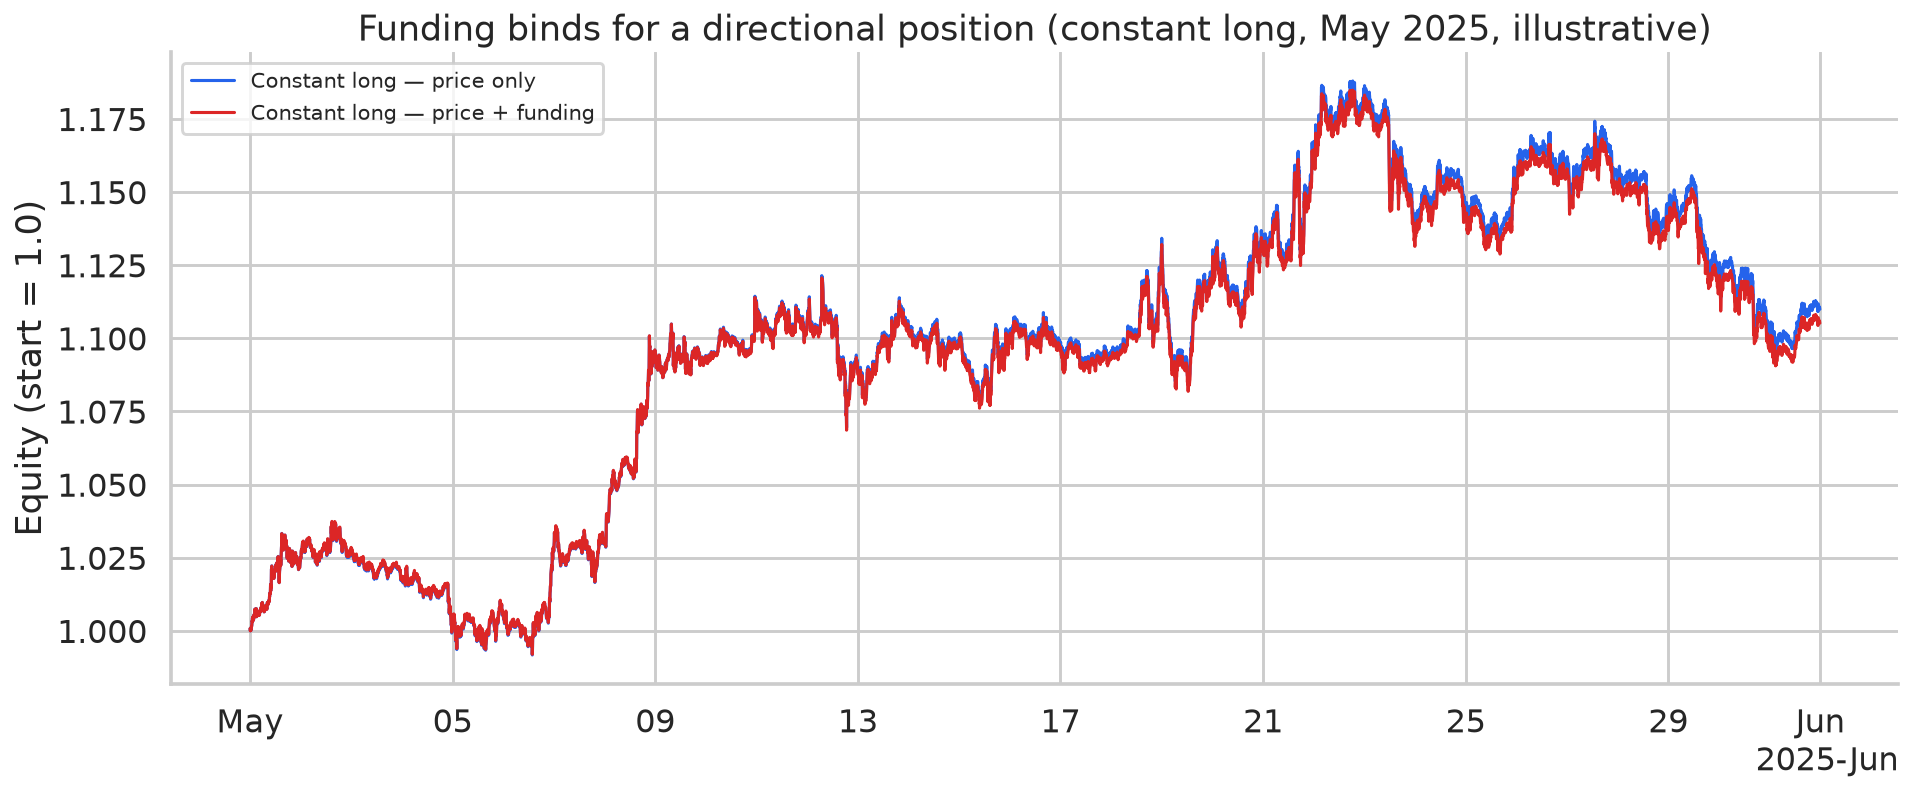

In [8]:
fret = df["close"].pct_change().shift(-1).to_numpy()          # return from t to t+1
# Funding charged to the position held into the next bar's settlement, priced at
# that pre-settlement bar's rate (funding_rate_ff at bar t, settled at bar t+1).
settle_next = df["is_settlement"].shift(-1, fill_value=False).to_numpy().astype(float)
funding_leg = df["funding_rate_ff"].to_numpy() * settle_next
fret_with_funding = fret - funding_leg

momentum = df["ret"].rolling(MOMENTUM_LOOKBACK).mean()
positions = {
    "Constant long": np.ones(len(df)),
    "1h momentum": np.sign(momentum).fillna(0.0).to_numpy(),
}

valid = np.isfinite(fret)
ts = df.loc[valid, "time"]
rows = []
curves = {}
for name, pos in positions.items():
    pos_v = np.nan_to_num(pos[valid])
    frame_p, price_only = run_position_backtest(ts, pos_v, np.nan_to_num(fret[valid]))
    frame_f, price_funding = run_position_backtest(ts, pos_v, np.nan_to_num(fret_with_funding[valid]))
    curves[name] = (frame_p, frame_f)
    # Realised-funding contribution to this position (additive approximation; a
    # simple sum of per-settlement cash flows, whereas returns compound).
    funding_contribution_pct = float(np.nansum(-pos_v * funding_leg[valid]) * 100.0)
    rows.append(
        {
            "position": name,
            "price_only_return_pct": price_only["net_return_pct"],
            "price_plus_funding_return_pct": price_funding["net_return_pct"],
            "funding_contribution_pct": funding_contribution_pct,
        }
    )

fig, ax = plt.subplots(figsize=(14, 6))
frame_p, frame_f = curves["Constant long"]
ax.plot(frame_p["timestamp"], frame_p["equity_curve"], color="#2563eb", linewidth=1.6, label="Constant long — price only")
ax.plot(frame_f["timestamp"], frame_f["equity_curve"], color="#dc2626", linewidth=1.6, label="Constant long — price + funding")
ax.set_title("Funding binds for a directional position (constant long, May 2025, illustrative)")
ax.set_ylabel("Equity (start = 1.0)")
ax.legend(frameon=True, fontsize=11)
format_time_axis(ax)
plt.tight_layout()

summary_table = pd.DataFrame(rows)
print(summary_table.to_markdown(index=False))
print(
    "\nfunding_contribution_pct is an additive approximation (sum of settlement cash flows); "
    "returns compound, so it need not reconcile exactly with the return columns. Note the "
    "direction-neutral momentum signal nets funding out almost entirely."
)

## 7. Chart 3 — Funding as a signal

As a bonus diagnostic — a bridge to alpha research, **not** a tradable
conclusion — test `position = -sign(funding_rate)` (fade the crowd paying to
hold). The economic point is that the position **collects** the funding, so we
evaluate it **with the funding leg included** (`price + funding`) alongside the
price-only curve; the gap between them *is* the carry. With ~90% of prints
positive this month the position is nearly a constant **short**, so the price-only
curve is mostly inverse-BTC, not evidence about funding as a signal.

Bridge to alpha research only — one month, one instrument, no costs, and ~constant short in this window. See notebooks/alpha-discovery.py for the full search framework.


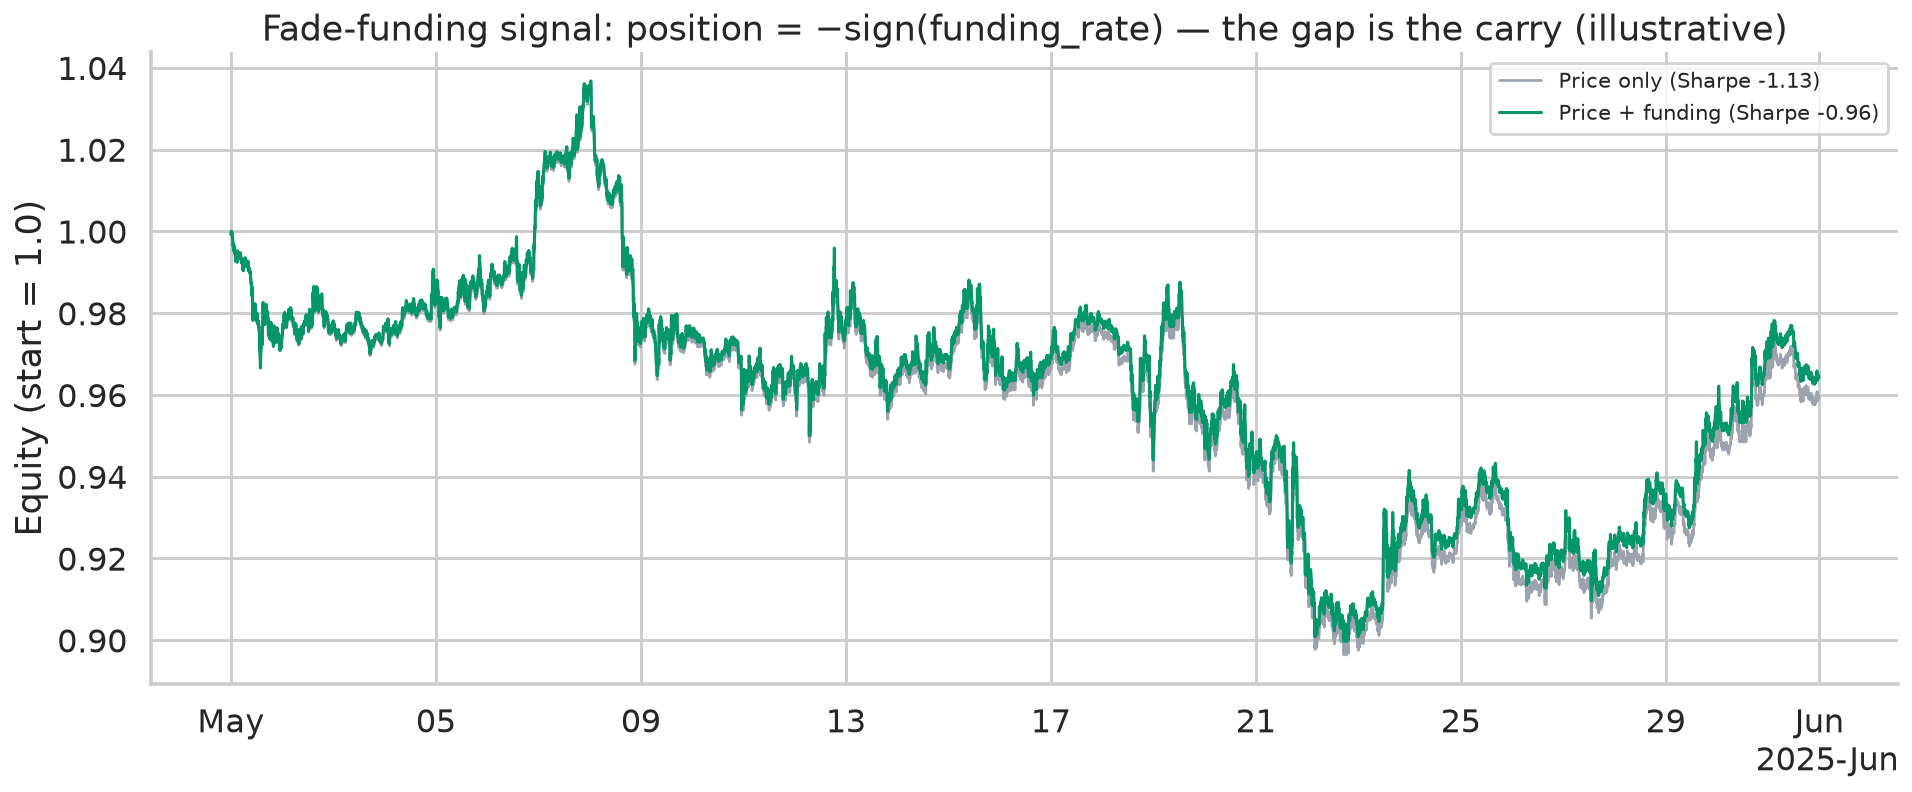

In [9]:
funding_ff = df["funding_rate_ff"]
signal_pos = -np.sign(funding_ff).fillna(0.0).to_numpy()
valid_s = np.isfinite(signal_pos) & np.isfinite(fret)
ts_s = df.loc[valid_s, "time"]
sig_v = np.nan_to_num(signal_pos[valid_s])
frame_price, summ_price = run_position_backtest(ts_s, sig_v, np.nan_to_num(fret[valid_s]))
frame_fund, summ_fund = run_position_backtest(ts_s, sig_v, np.nan_to_num(fret_with_funding[valid_s]))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(frame_price["timestamp"], frame_price["equity_curve"], color="#9ca3af", linewidth=1.4, label=f"Price only (Sharpe {summ_price['annualized_sharpe']:.2f})")
ax.plot(frame_fund["timestamp"], frame_fund["equity_curve"], color="#059669", linewidth=1.6, label=f"Price + funding (Sharpe {summ_fund['annualized_sharpe']:.2f})")
ax.set_title("Fade-funding signal: position = −sign(funding_rate) — the gap is the carry (illustrative)")
ax.set_ylabel("Equity (start = 1.0)")
ax.legend(frameon=True, fontsize=11)
format_time_axis(ax)
plt.tight_layout()
print(
    "Bridge to alpha research only — one month, one instrument, no costs, and ~constant short "
    "in this window. See notebooks/alpha-discovery.py for the full search framework."
)

## Takeaways

- **Funding is real PnL, and direction decides whether it binds.** For the
  constant long it is a first-order cost (Section 6, and the ~-0.43%/month in
  Chart 2); for the direction-neutral momentum signal it nets out almost entirely.
  A long-biased backtest that omits funding overstates its edge.
- **Accrue at the settlement, to the position held into it.** Funding is charged
  at the 8-hour prints using the pre-settlement rate — not smeared across every
  5-minute bar and not attributed to a position entered after the print.
- **`funding_rate` is a per-print rate, annualize it only for display.** A print
  of 1bp is 1bp of notional at that settlement (~11%/year at 3 prints/day), not
  1bp/year — every PnL figure above charges the raw per-print value; the
  annualized (%) figures (coverage table, Chart 1's right axis) are for scale
  comparisons only and never feed back into a cash-flow calculation.
- **Realised, not predicted.** Everything here accounts for prints that already
  happened; the catalogue has no predicted-funding metric.
- **One month proves nothing.** The figures — including the fade-funding
  diagnostic — are illustrative, not evidence of persistence.

## Further reading
- [Improve your backtest](https://aperiodic.io/use-cases/improve-your-backtest)
- [Derivatives metrics](https://aperiodic.io/metrics/derivatives)
- Cost-model companion: `notebooks/backtest-slippage.py`
- Related notebook: `notebooks/alpha-discovery.py`